# 08 · Mixed-effects robustness

This notebook presents a trial-level mixed-effects check for the selected primary hooks. It is the reviewer-facing complement to the aggregate and participant-level robustness notebooks.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "results").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import *

P = paths(ROOT)
FIG = P["figures"]
set_style()
pd.set_option("display.precision", 3)

MIXED = ROOT / "reports/mixed_effects/mixed_effects_primary.csv"
me = pd.read_csv(MIXED)

## Model specification

For each corpus, timing state, and representation, I fit this model at the **individual trial** level:

```text
trial log RT ~ baseline prediction + representation gain +
               (1 | participant) + (1 | word/item)
```

where:

- **baseline prediction** is the held-out surprisal-baseline prediction from the main SAE-regression pipeline.
- **representation gain** is `model prediction − baseline prediction`.
- `(1 | participant)` controls for reader-specific speed.
- `(1 | word/item)` controls for item-specific difficulty.

The key coefficient is **representation gain**. A positive coefficient means that the dense or SAE model adds trial-level explanatory signal beyond the baseline, even after accounting for participant and item variation.

These models were fit in R with `lme4/lmerTest` using maximum likelihood. The likelihood-ratio test compares the full model against the same mixed model without the representation-gain term.

In [2]:
table = me.copy()
table["ΔAIC"] = table["aic_baseline"] - table["aic_with_delta"]
table["β gain 95% CI"] = table.apply(lambda r: f"{r.delta_beta:+.4f} [{r.delta_beta - 1.96*r.delta_se:+.4f}, {r.delta_beta + 1.96*r.delta_se:+.4f}]", axis=1)
table["LRT p"] = table["lrt_p"].map(lambda p: "< .001" if p < .001 else f"{p:.3f}")
show = table[["dataset", "state", "representation_label", "hook", "n_trials", "n_participants", "n_items",
              "β gain 95% CI", "delta_t", "LRT p", "ΔAIC"]].copy()
show.columns = ["Dataset", "State", "Representation", "Hook", "Trials", "Participants", "Items",
                "β for representation gain", "t", "LRT p", "ΔAIC"]
display(focus_table(show.round({"t": 2, "ΔAIC": 1}), important=["β for representation gain", "LRT p", "ΔAIC"],
                    caption="Crossed participant/item mixed-effects models. Positive β means the representation gain predicts trial-level RT beyond the baseline."))

Dataset,State,Representation,Hook,Trials,Participants,Items,β for representation gain,t,LRT p,ΔAIC
Provo,Before word,Dense state,L01,153566,84,2743,"+0.0104 [+0.0070, +0.0139]",5.940000,< .001,33.000000
Provo,Before word,SAE features,L01,153566,84,2743,"+0.0183 [+0.0149, +0.0217]",10.590000,< .001,108.000000
Provo,After word,Dense state,L01,153566,84,2743,"+0.0196 [+0.0162, +0.0230]",11.190000,< .001,120.500000
Provo,After word,SAE features,L01,153566,84,2743,"+0.0251 [+0.0218, +0.0285]",14.740000,< .001,207.100000
Natural Stories,Before word,Dense state,L08,847310,169,10256,"+0.0112 [+0.0098, +0.0127]",15.270000,< .001,228.300000
Natural Stories,Before word,SAE features,L08,847310,169,10256,"+0.0074 [+0.0060, +0.0089]",10.020000,< .001,97.900000
Natural Stories,After word,Dense state,L08,847310,169,10256,"+0.0147 [+0.0133, +0.0161]",20.690000,< .001,417.200000
Natural Stories,After word,SAE features,L08,847310,169,10256,"+0.0104 [+0.0091, +0.0118]",14.680000,< .001,211.100000


## Fixed effect of representation gain

The y-axis is the fixed-effect coefficient for the representation-gain term. The predictor is z-scored, so the coefficient is the expected change in log RT for a one-standard-deviation increase in the extra prediction supplied by the dense or SAE model.

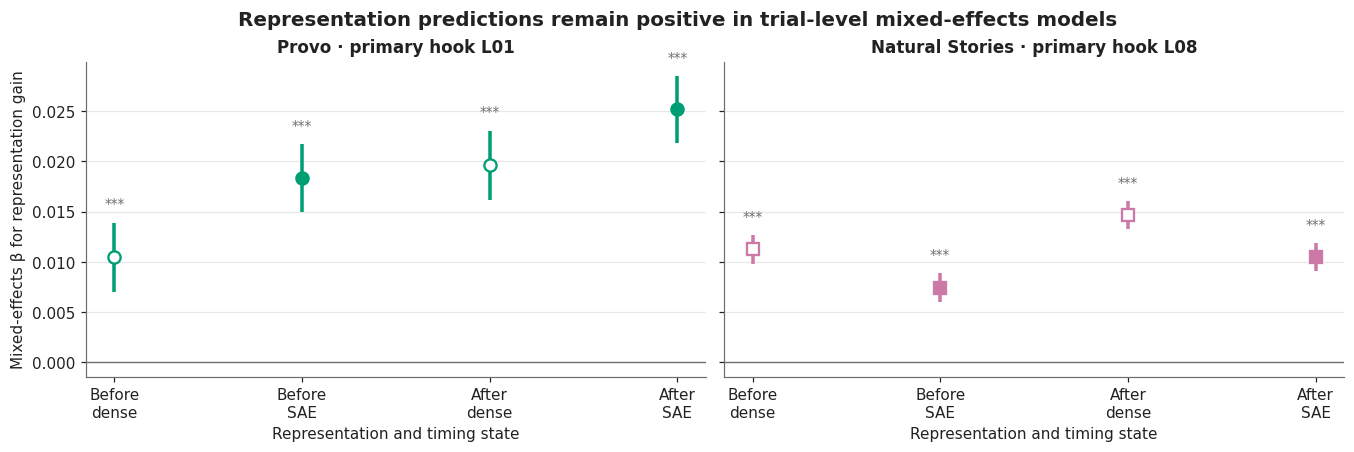

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.0), layout="constrained", sharey=True)
order = [("prefix", "dense"), ("prefix", "sae"), ("post", "dense"), ("post", "sae")]
labels = ["Before\ndense", "Before\nSAE", "After\ndense", "After\nSAE"]

for ax, corpus in zip(axes, CORPORA):
    g = me[me.corpus == corpus].copy()
    color = CORPUS_COLORS[corpus]
    for i, (kind, rep) in enumerate(order):
        r = g[(g.kind == kind) & (g.representation == rep)].iloc[0]
        mfc = color if rep == "sae" else "white"
        lo = r.delta_beta - 1.96 * r.delta_se
        hi = r.delta_beta + 1.96 * r.delta_se
        ax.vlines(i, lo, hi, color=color, lw=2.3)
        ax.plot(i, r.delta_beta, marker=CORPUS_MARKERS[corpus], color=color, mfc=mfc, mew=1.5, ms=8)
        ax.text(i, hi + 0.0012, "***" if r.lrt_p < .001 else f"p={r.lrt_p:.3f}",
                ha="center", va="bottom", fontsize=9, color=MUTED)
    ax.axhline(0, color=MUTED, lw=0.9)
    ax.set_xticks(range(len(order)), labels)
    ax.set_title(f"{CORPUS_LABELS[corpus].split(' ·')[0]} · primary hook {g.hook.iloc[0]}")
    ax.set_xlabel("Representation and timing state")
    ax.grid(axis="y", color=GRID)
axes[0].set_ylabel("Mixed-effects β for representation gain")
fig.suptitle("Representation predictions remain positive in trial-level mixed-effects models", fontsize=13, fontweight="bold")
save_figure(fig, FIG, "08_mixed_effects_gain_beta")
plt.show()

## Model-comparison view

The likelihood-ratio test asks whether adding the representation-gain term improves the crossed mixed model. ΔAIC is shown as baseline AIC minus full-model AIC, so larger positive values mean the representation-gain model fits better.

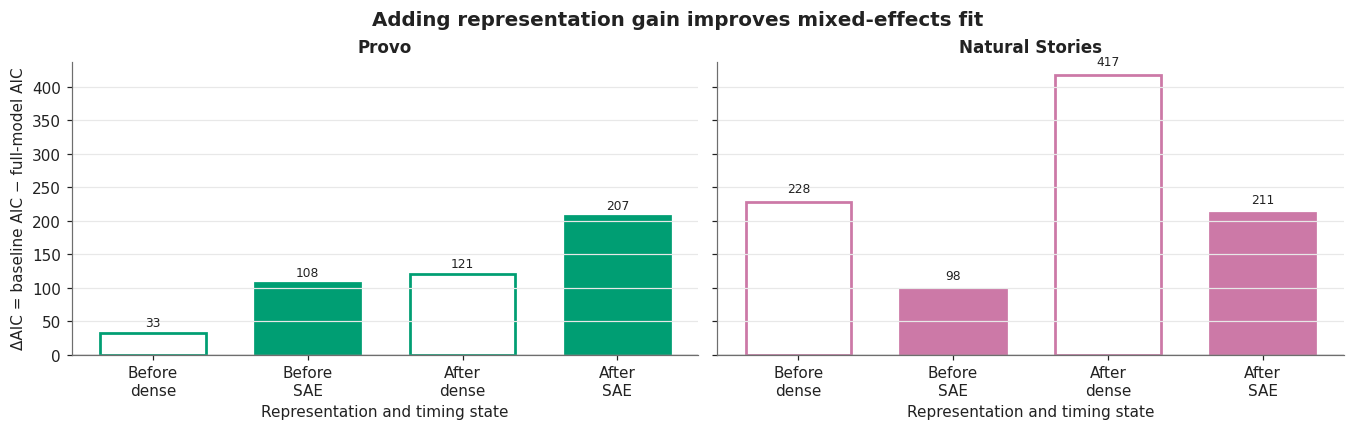

In [4]:
plot = me.copy()
plot["delta_aic"] = plot.aic_baseline - plot.aic_with_delta
fig, axes = plt.subplots(1, 2, figsize=(12.2, 3.8), layout="constrained", sharey=True)

for ax, corpus in zip(axes, CORPORA):
    g = plot[plot.corpus == corpus]
    color = CORPUS_COLORS[corpus]
    for i, (kind, rep) in enumerate(order):
        r = g[(g.kind == kind) & (g.representation == rep)].iloc[0]
        mfc = color if rep == "sae" else "white"
        ax.bar(i, r.delta_aic, color=color if rep == "sae" else "white", edgecolor=color, linewidth=1.8, width=0.68)
        ax.text(i, r.delta_aic + max(g.delta_aic) * 0.025, f"{r.delta_aic:.0f}", ha="center", va="bottom", fontsize=8, color=INK)
    ax.axhline(0, color=MUTED, lw=0.9)
    ax.set_xticks(range(len(order)), labels)
    ax.set_title(f"{CORPUS_LABELS[corpus].split(' ·')[0]}")
    ax.grid(axis="y", color=GRID)
    ax.set_xlabel("Representation and timing state")
axes[0].set_ylabel("ΔAIC = baseline AIC − full-model AIC")
fig.suptitle("Adding representation gain improves mixed-effects fit", fontsize=13, fontweight="bold")
save_figure(fig, FIG, "08_mixed_effects_delta_aic")
plt.show()

## How to report this

The mixed-effects check supports the main direction of the project: selected dense and SAE predictions add trial-level signal beyond the surprisal baseline after controlling for participant and item variation.

The cleanest verbal summary is:

> In crossed participant/item mixed-effects models, the representation-gain term was positive for every selected comparison. The effect was strongest for Provo after-word SAE and Natural Stories after-word dense, matching the broader pattern that after-word representations carry strong reading-time signal.

This does not replace the held-out aggregate evaluation, because the mixed model reuses fixed predictions from that pipeline. It answers a different reviewer question: whether the effect survives participant and item random intercepts at the trial level.